In [13]:
import os
from dotenv import load_dotenv

# Change working directory to the parent folder
os.chdir(os.path.abspath(".."))
load_dotenv()

True

In [14]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import START, END
from langgraph.graph.state import StateGraph
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition
from langchain_core.tools import tool
from langchain_core.messages import BaseMessage

print("Import Successful")

Import Successful


In [15]:
import os 
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")
os.environ["LANGSMITH_API_KEY"] = os.getenv("LANGSMITH_API_KEY")
os.environ["LANGSMITH_TRACING"] = "true"

print("Environment variables loaded")

Environment variables loaded


In [16]:
class State(TypedDict):
    messages:Annotated[list[BaseMessage], add_messages]

In [17]:
## Initilize llm model

from langchain.chat_models import init_chat_model
llm = init_chat_model("groq:qwen/qwen3.8-27b")
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.6.3', 'langchain': '1.4.2'}}, client=<groq.resources.chat.completions.Completions object at 0x10ed91d10>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x10ed90cd0>, model_name='qwen/qwen3.8-27b', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [18]:
## Graph with tool

@tool
def add(a:float, b:float) -> float:
    """Add two numbers"""

    return a+b
tools=[add]
tool_node = ToolNode([add])
llm_wiht_tool = llm.bind_tools(tools)

In [19]:
def call_llm_nodek(state:State):
    return {"messages":[llm_wiht_tool.invoke(state['messages'])]}

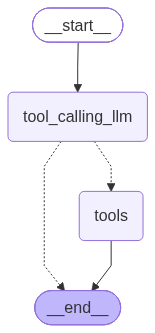

In [20]:
## Create State Graph


builder = StateGraph(State)
builder.add_node("tool_calling_llm", call_llm_nodek)
builder.add_node("tools", ToolNode(tools))

## Add edgs

builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges("tool_calling_llm", tools_condition)
builder.add_edge("tools", END)

## Compile the graph

graph = builder.compile()
graph


In [21]:
response = graph.invoke({"messages":"What is machine learning"})
response

{'messages': [HumanMessage(content='What is machine learning', additional_kwargs={}, response_metadata={}, id='e7ecac7f-0813-4ea6-b3ad-f6cff7631ec2'),
  AIMessage(content='Machine learning is a branch of artificial intelligence (AI) that focuses on building systems that can learn from data and improve their performance on a task over time, without being explicitly programmed for every specific rule.\n\n### Key Concepts:\n1. **Learning from Data**: Instead of using hard-coded rules, machine learning algorithms identify patterns in large datasets.\n2. **Generalization**: The goal is to make accurate predictions or decisions on new, unseen data.\n3. **Models**: These are mathematical representations trained on data. Common types include linear regression, decision trees, neural networks, etc.\n\n### Main Types of Machine Learning:\n- **Supervised Learning**: The model learns from labeled data (input-output pairs). Example: Spam detection.\n- **Unsupervised Learning**: The model finds hidd

In [22]:
response = graph.invoke({"messages":"What  2 + 2"})
response

{'messages': [HumanMessage(content='What  2 + 2', additional_kwargs={}, response_metadata={}, id='a4c6a3b8-ae79-4e00-a7ce-55a225ce941c'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'rh3yqwqgb', 'function': {'arguments': '{"a":2,"b":2}', 'name': 'add'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 35, 'prompt_tokens': 285, 'total_tokens': 320, 'completion_time': 0.068696925, 'completion_tokens_details': None, 'prompt_time': 0.02016769, 'prompt_tokens_details': None, 'queue_time': 0.049946839, 'total_time': 0.088864615}, 'model_name': 'qwen/qwen3.8-27b', 'system_fingerprint': 'fp_424cb89518', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a1113d-5c2d-78c3-9805-7f35c2d573d0-0', tool_calls=[{'name': 'add', 'args': {'a': 2, 'b': 2}, 'id': 'rh3yqwqgb', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 285, 'output_tokens': 35, 'total_toke

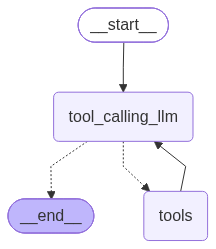

In [23]:
## Create State Graph

builder = StateGraph(State)
builder.add_node("tool_calling_llm", call_llm_nodek)
builder.add_node("tools", ToolNode(tools))

## Add edgs

builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges("tool_calling_llm", tools_condition)
builder.add_edge("tools", "tool_calling_llm")

## Compile the graph

graph = builder.compile()
graph


In [24]:
responseresponse = graph.invoke({"messages":"What is 5 + 20"})
response


{'messages': [HumanMessage(content='What  2 + 2', additional_kwargs={}, response_metadata={}, id='a4c6a3b8-ae79-4e00-a7ce-55a225ce941c'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'rh3yqwqgb', 'function': {'arguments': '{"a":2,"b":2}', 'name': 'add'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 35, 'prompt_tokens': 285, 'total_tokens': 320, 'completion_time': 0.068696925, 'completion_tokens_details': None, 'prompt_time': 0.02016769, 'prompt_tokens_details': None, 'queue_time': 0.049946839, 'total_time': 0.088864615}, 'model_name': 'qwen/qwen3.8-27b', 'system_fingerprint': 'fp_424cb89518', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a1113d-5c2d-78c3-9805-7f35c2d573d0-0', tool_calls=[{'name': 'add', 'args': {'a': 2, 'b': 2}, 'id': 'rh3yqwqgb', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 285, 'output_tokens': 35, 'total_toke

In [25]:
## setup langsmith project 
os.environ["LANGSMITH_PROJECT"] = os.getenv("LANGSMITH_PROJECT")